In [2]:
import os
import sys
path = os.path.abspath("")
splitted = path.split(os.sep)
user_independent = os.path.join(splitted[0]+os.sep, splitted[1], splitted[2], splitted[3])
src_path = os.path.join(user_independent, 'GitHub', 'Photoswitching')
sys.path.append(src_path)

import src.antibunching as ab
import src.blinking as bl
import src.distributions as dist
import src.emissions as em
import src.fcs as fc
import src.figure as fi
import src.fluorophores as fl
import src.formulas as fo
import src.miscellaneous as mi
import src.network as net
import src.simulation as si
import src.statistics as st
import src.tcspc as tc
import src.transitions as tr

import numpy as np
import pandas as pd
%load_ext autoreload
%autoreload 2

import warnings
def custom_warning_format(msg, category, filename, lineno, line=None):
    if line is None:
        import linecache
        line = linecache.getline(filename, lineno)
    return f'WARNING for line: {line} {msg} \n' 
warnings.formatwarning = custom_warning_format

In [3]:
fluorophore = fl.Fluorophore(name='atto643', position=[0, 0])
fluorophore_system = fl.FluorophoreSystem([fluorophore])

WARNING for line:             warnings.warn(f'Fluorophore {self.name} not known. Parameters have to be defined manually.')
 Fluorophore atto643 not known. Parameters have to be defined manually. 


In [4]:
fluorescence_lifetime = 3e-9
triplet_lifetime = 5e-6
triplet_yield = 0.2
fluorescence_yield = 0.6
internal_conversion_yield = 0.2
extinction_coeff = 1.5e5
off_lifetime = 10
h2o_rate = 3e4
wavelength = 643
irradiance = 2.5 
frame = '5ms'
photon_collection_rate = 0.01
emccd_gain = 10

In [6]:
wavenumber, wavelength, frequency = fo.convert_wavenumber_wavelength_frequency(wavelength=wavelength)
photon_flux = fo.calculate_photon_flux(irradiance=irradiance, frequency=frequency)
excitation_rate = fo.calculate_excitation_rate(photon_flux=photon_flux, extinction_coefficient=extinction_coeff)
emission_rate = fo.calculate_emission_rate(quantum_yield=fluorescence_yield, fluorescence_lifetime=fluorescence_lifetime)
isc_st_rate = fo.calculate_emission_rate(quantum_yield=triplet_yield, fluorescence_lifetime=fluorescence_lifetime)
isc_ts_rate = 1/triplet_lifetime
internal_conversion_rate = fo.calculate_emission_rate(quantum_yield=internal_conversion_yield, fluorescence_lifetime=fluorescence_lifetime)
excitation = tr.Transition(tr.TransitionType.EXCITATION, excitation_rate)
emission = tr.Transition(tr.TransitionType.FLUORESCENT_EMISSION, emission_rate)
isc_st = tr.Transition(tr.TransitionType.INTERSYSTEM_CROSSING_ST, isc_st_rate)
isc_ts = tr.Transition(tr.TransitionType.INTERSYSTEM_CROSSING_TS, isc_ts_rate)
internal_conversion = tr.Transition(tr.TransitionType.INTERNAL_CONVERSION_S, internal_conversion_rate)
h2o_attack = tr.Transition(tr.TransitionType.H2O_ATTACK_S, h2o_rate)
back_reaction = tr.Transition(tr.TransitionType.BACK_REACTION, 1/off_lifetime)

transitions = [excitation, emission, internal_conversion, isc_st, isc_ts, h2o_attack, back_reaction]

<Axes: >

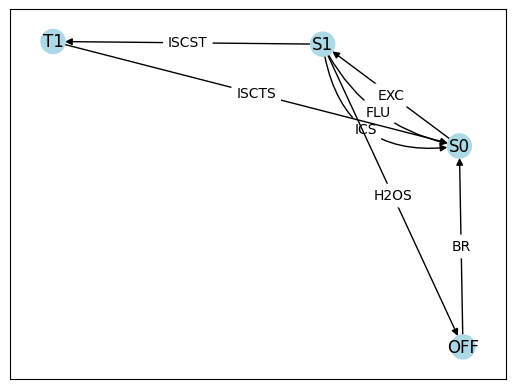

In [7]:
transition_set = tr.TransitionSet(transitions, fluorophore_system)
transition_set.finalize()
transition_set.plot('kamadar')

In [8]:
prediction = st.Prediction(transition_set)
simulation = si.Simulation(transition_set)
simulation.approximate(prediction=prediction, 
                       strategy='individual', size=1e7, seed=3)

In [9]:
analysis = st.Analysis(simulation)
emissions = em.Emissions(simulation, photon_collection_rate=photon_collection_rate, resample=frame, emccd_gain=emccd_gain, 
                         seed=100)
fcs = fc.FCS(emissions).autocorrelate_time_points(exp_min=-8, exp_max=1)
blinking = bl.Blinking(emissions)

events = emissions.event_time_series
events = events[events != 0]
treat_mean_intensity = events.mean()

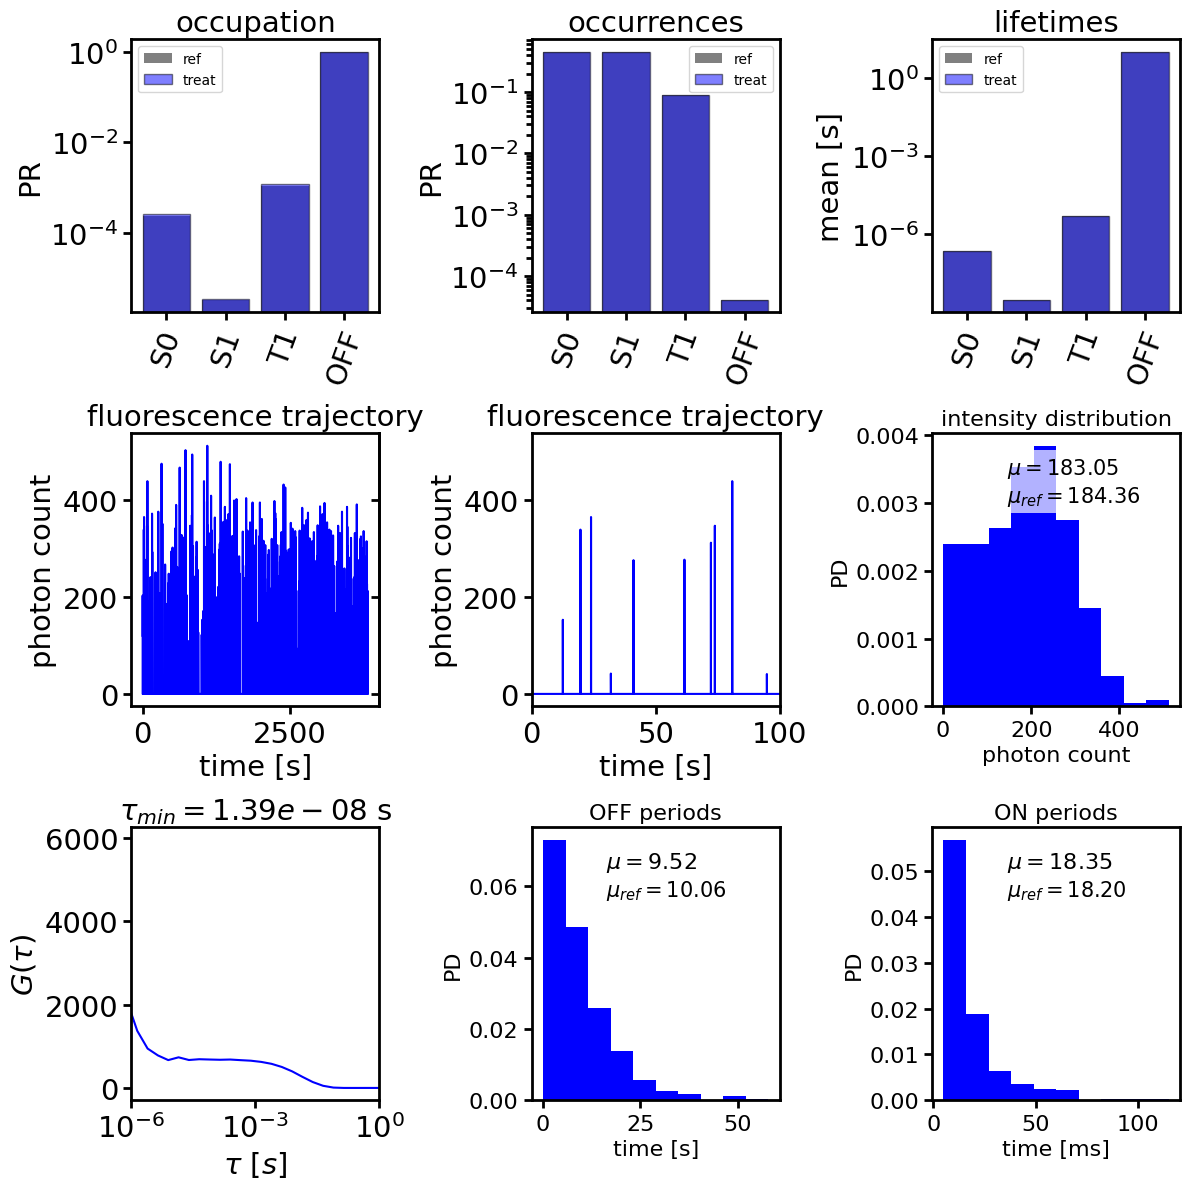

In [10]:
states = np.arange(transition_set.single_states.size)
ref_state_occupations = np.array([2.39269713e-04, 3.33060803e-06, 1.11033556e-03, 9.98647064e-01])
ref_state_occurrences = np.array([4.54541825e-01, 4.54541825e-01, 9.08750391e-02, 4.13099996e-05])
ref_mean_lifetimes = np.array([2.15455246e-07, 2.99911327e-09, 5.00095424e-06, 9.89464082e+00])
ref_mean_on_periods = 18.204433497536943
ref_mean_off_periods = 10.063108374384237
ref_mean_intensity = 184.35896915584416
axes = fi.universal_figure(nrows=3, ncols=3, fig_height=12, fig_width=12, type_='bar', data=[states, ref_state_occupations], color='grey', label='ref')
analysis.plot(axes=axes[0, 0], mode='state_occupations', alpha=0.5, label='treat', legend=True)
fi.universal_figure(type_='bar', data=[states, ref_state_occurrences], color='grey', axes=axes[0, 1], label='ref')
analysis.plot(axes=axes[0, 1], mode='state_occurrences', alpha=0.5, label='treat', legend=True)
fi.universal_figure(type_='bar', data=[states, ref_mean_lifetimes], color='grey', axes=axes[0, 2], label='ref')
analysis.plot(axes=axes[0, 2], mode='mean_lifetimes', alpha=0.5, label='treat', legend=True)
emissions.plot(axes=axes[1, 0], mode='time_series', second_axis_y=True)
emissions.plot(axes=axes[1, 1], mode='time_series', xlim=[0, 100])
emissions.plot(axes=axes[1, 2], mode='histogram', display_mean=False)
axes[1, 2].text(x=0.3, y=0.75, s=fr"$\mu = {treat_mean_intensity:.2f}$""\n"fr"$\mu_{{ref}} = {ref_mean_intensity:.2f}$", transform=axes[1, 2].transAxes, bbox=dict(facecolor='w', edgecolor='none', alpha=0.7), fontsize=15)
fcs.plot(axes=axes[2, 0], xticks=[1e-6, 1e-3, 1e0], xlim=[1e-6, 1e0])
blinking.plot(axes=axes[2, 1], mode='off_histogram', as_time='s')
axes[2, 1].text(x=0.3, y=0.75, s=fr"$\mu_{{ref}} = {ref_mean_off_periods:.2f}$", transform=axes[2, 1].transAxes, fontsize=15)
blinking.plot(axes=axes[2, 2], mode='on_histogram', as_time='ms')
axes[2, 2].text(x=0.3, y=0.75, s=fr"$\mu_{{ref}} = {ref_mean_on_periods:.2f}$", transform=axes[2, 2].transAxes, fontsize=15)

axes[0, 0].get_figure().tight_layout()